# Projeto de Logística

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

base_path = r"dados.db"

orders = pd.read_csv(
    f"{base_path}/olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

order_items = pd.read_csv(f"{base_path}/olist_order_items_dataset.csv")
products = pd.read_csv(f"{base_path}/olist_products_dataset.csv")
customers = pd.read_csv(f"{base_path}/olist_customers_dataset.csv")
reviews = pd.read_csv(
    f"{base_path}/olist_order_reviews_dataset.csv",
    parse_dates=["review_creation_date", "review_answer_timestamp"]
)

print("Dados carregados:")
print(f"orders: {orders.shape}")
print(f"order_items: {order_items.shape}")
print(f"products: {products.shape}")
print(f"customers: {customers.shape}")
print(f"reviews: {reviews.shape}")

Dados carregados:
orders: (99441, 8)
order_items: (112650, 7)
products: (32951, 9)
customers: (99441, 5)
reviews: (99224, 7)


In [ ]:
# Preparação da base de dados de logística para a categoria moveis_decoracao
orders_log = orders.copy()
products_moveis = products.loc[
    products["product_category_name"] == "moveis_decoracao",
    ["product_id"]
]
order_items_moveis = order_items.merge(products_moveis, on="product_id", how="inner")
orders_log = orders_log.merge(
    order_items_moveis[["order_id"]].drop_duplicates(),
    on="order_id",
    how="inner"
)

orders_log["order_year"] = orders_log["order_purchase_timestamp"].dt.year
orders_log["processing_time_days"] = (
    (orders_log["order_approved_at"] - orders_log["order_purchase_timestamp"]).dt.total_seconds() / 86400
)
orders_log["delivery_delay_days"] = (
    (orders_log["order_delivered_customer_date"] - orders_log["order_estimated_delivery_date"]).dt.total_seconds() / 86400
)
orders_log["late_delivery"] = orders_log["delivery_delay_days"] > 0
orders_log["on_time_delivery"] = orders_log["delivery_delay_days"] <= 0

# Parâmetro para pegar feedbacks escritos relacionados a logística
feedback_keyword = "logistica"

logistics_reviews = reviews.copy()
logistics_reviews = logistics_reviews.loc[logistics_reviews["order_id"].isin(orders_log["order_id"])]
logistics_reviews["has_logistica"] = logistics_reviews["review_comment_message"].fillna("").str.lower().str.contains(feedback_keyword)
logistics_reviews["review_text"] = logistics_reviews["review_comment_message"].fillna("")

summary_sample = orders_log.loc[orders_log["order_year"].notna(), [
    "order_id", "customer_id", "order_year", "order_status", "processing_time_days", "delivery_delay_days", "late_delivery"
]].head(5)
print(summary_sample)

                           order_id                       customer_id  \
0  76c6e866289321a7c93b82b54852dc33  f54a9f0e6b351c431402b8461ea51999   
1  989225ba6d0ebd5873335f7e01de2ae7  816f8653d5361cbf94e58c33f2502a5c   
2  25f4376934e13d3508486352e11a5db0  12fd2740039676063a874b9567dfa651   
3  e425680f760cbc130be3e53a9773c584  f178c1827f67a8467b0385b7378d951a   
4  a685d016c8a26f71a0bb67821070e398  911e4c37f5cafe1604fe6767034bf1ae   

   order_year order_status  processing_time_days  delivery_delay_days  \
0        2017    delivered              1.348356           -31.410995   
1        2017    delivered              1.998715            -4.247500   
2        2018    delivered              0.346157            -3.359595   
3        2017    delivered              0.010336           -15.125058   
4        2017    delivered              0.000000             7.567546   

   late_delivery  
0          False  
1          False  
2          False  
3          False  
4           True  


In [17]:
# Métricas de performance logística
performance_by_year = (
    orders_log
    .groupby("order_year")
    .agg(
        total_orders=("order_id", "nunique"),
        avg_processing_days=("processing_time_days", "mean"),
        avg_delivery_delay=("delivery_delay_days", "mean"),
        pct_late_delivery=("late_delivery", "mean")
    )
    .reset_index()
)
performance_by_year["pct_late_delivery"] = performance_by_year["pct_late_delivery"] * 100
performance_by_year

,order_year,total_orders,avg_processing_days,avg_delivery_delay,pct_late_delivery
0,2016,52,1.459881,-38.754606,0.000000
1,2017,3198,0.443796,-11.764553,7.817386
2,2018,3199,0.489107,-11.124481,8.909034


In [18]:
# Estados com maior volume de pedidos e maior taxa de atraso
orders_customers = orders_log.merge(customers, on="customer_id", how="left")
state_performance = (
    orders_customers
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "nunique"),
        avg_delay=("delivery_delay_days", "mean"),
        pct_late_delivery=("late_delivery", "mean")
    )
    .reset_index()
    .sort_values("total_orders", ascending=False)
)
state_top = state_performance.head(10)
state_top

,customer_state,total_orders,avg_delay,pct_late_delivery
25,SP,2724,-11.413670,0.055800
18,RJ,858,-10.806008,0.136364
10,MG,727,-13.159008,0.048143
22,RS,444,-13.571224,0.078829
17,PR,397,-12.354308,0.062972
23,SC,276,-10.411085,0.134058
4,BA,202,-8.665359,0.178218
7,ES,114,-11.925032,0.114035
6,DF,109,-11.471510,0.110092
8,GO,104,-10.140984,0.115385


In [ ]:
# Análise de reviews relacionados à logística
positive_keywords = [
    "muito bom", "indico", "parabens", "parabéns", "excelente",
    "ótimo", "otimo", "recomendo", "bom", "maravilhoso", "top",
    "ótima", "otima", "perfeito"
]

logistics_feedback = logistics_reviews.loc[logistics_reviews["has_logistica"]].copy()
logistics_feedback["review_score_label"] = logistics_feedback["review_score"].apply(
    lambda x: "sem nota" if pd.isna(x) else str(int(x))
)
logistics_feedback["review_score_filled"] = logistics_feedback["review_score"].fillna(-1)

feedback_summary = (
    logistics_feedback
    .groupby("review_score_label")
    .size()
    .reset_index(name="count")
)

score_order = {"1": 1, "2": 2, "3": 3, "4": 4, "5": 5, "sem nota": 6}
feedback_summary = feedback_summary.assign(order_key=feedback_summary["review_score_label"].map(score_order))
feedback_summary = feedback_summary.sort_values("order_key").drop(columns="order_key")

feedback_example = logistics_feedback[["order_id", "review_score", "review_score_label", "review_comment_message"]].head(10)


def contains_positive(text):
    txt = str(text).lower()
    return any(keyword in txt for keyword in positive_keywords)

positive_reviews = logistics_feedback.loc[
    logistics_feedback["review_comment_message"].fillna("").apply(contains_positive)
].copy()

positive_reviews["matched_keywords"] = positive_reviews["review_comment_message"].str.lower().apply(
    lambda text: ", ".join([kw for kw in positive_keywords if kw in text])
)

positive_summary = (
    positive_reviews
    .groupby("matched_keywords")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

positive_reviews_sample = positive_reviews[["order_id", "review_score", "review_score_label", "matched_keywords", "review_comment_message"]].head(20)

feedback_summary, feedback_example, positive_summary, positive_reviews_sample

(Empty DataFrame
 Columns: [review_score, count]
 Index: [],
 Empty DataFrame
 Columns: [order_id, review_score, review_comment_message]
 Index: [])

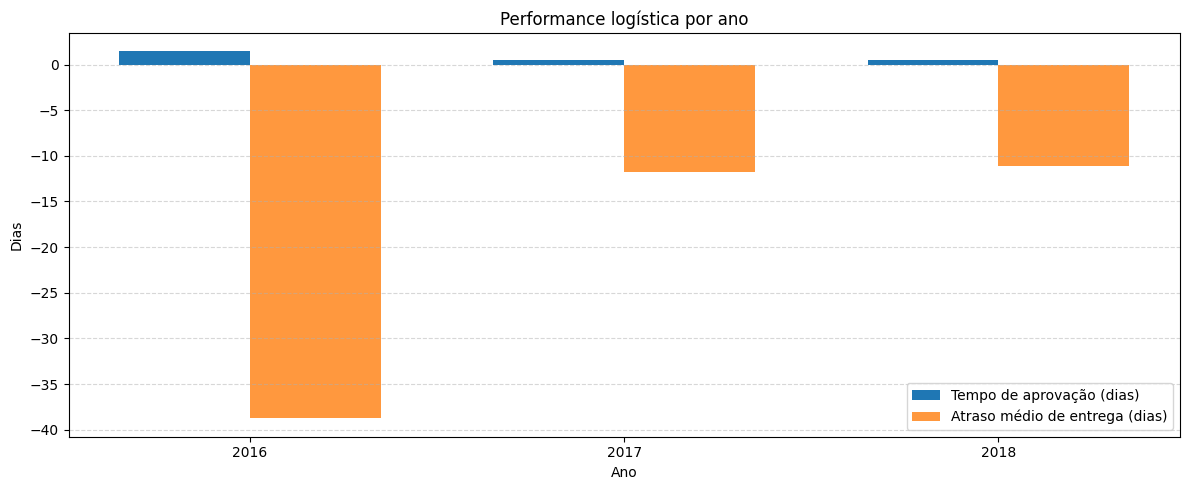

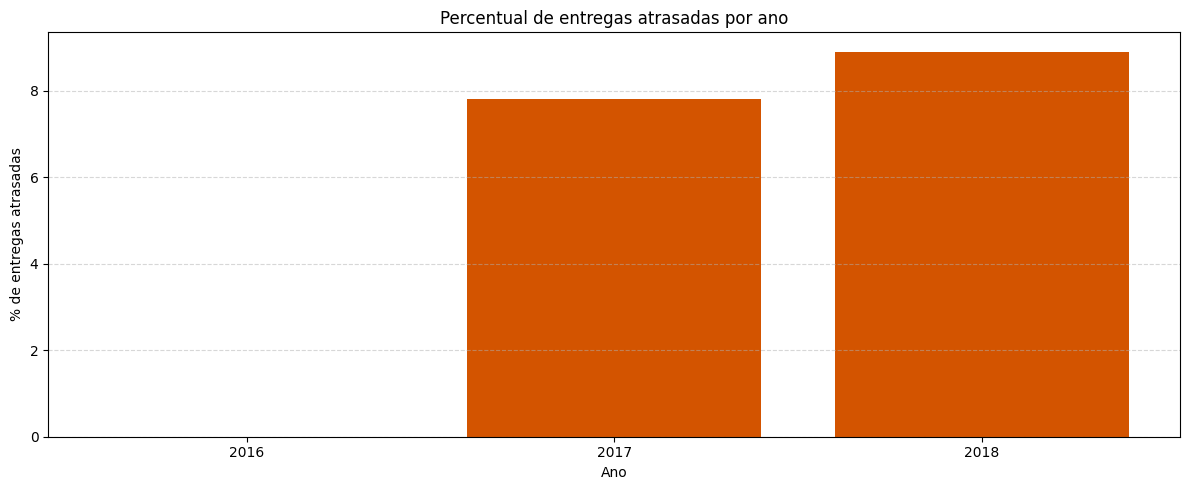

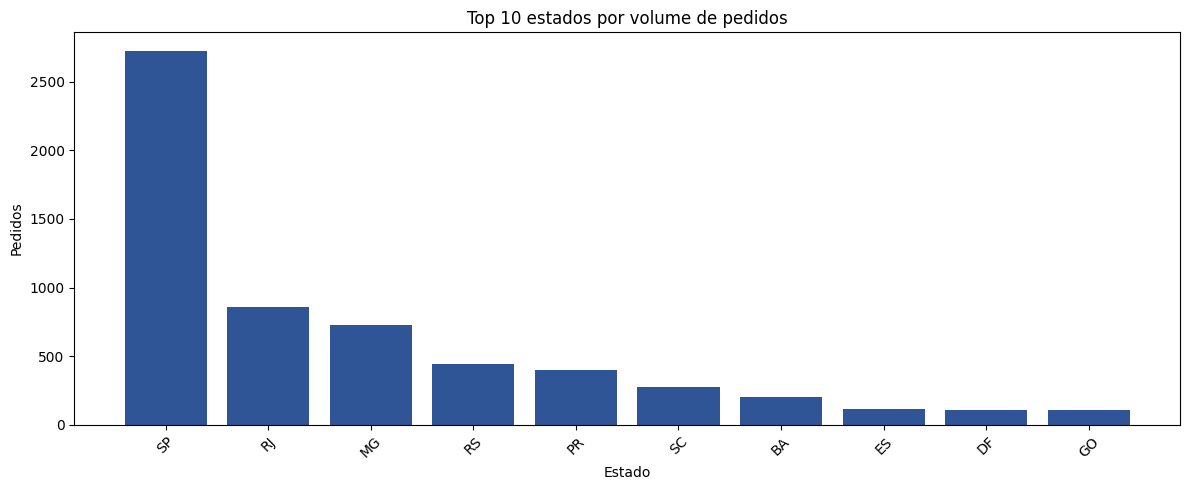

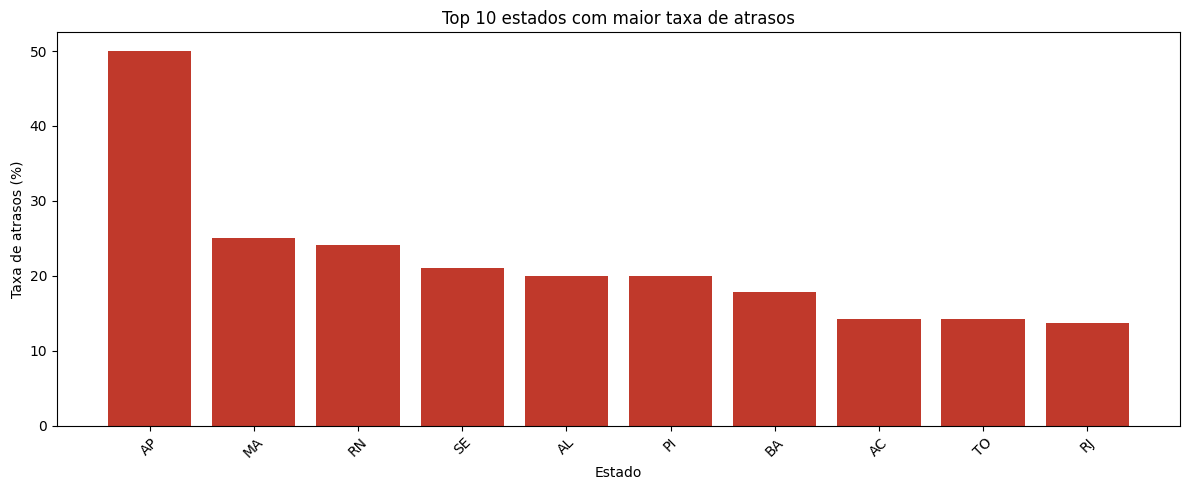

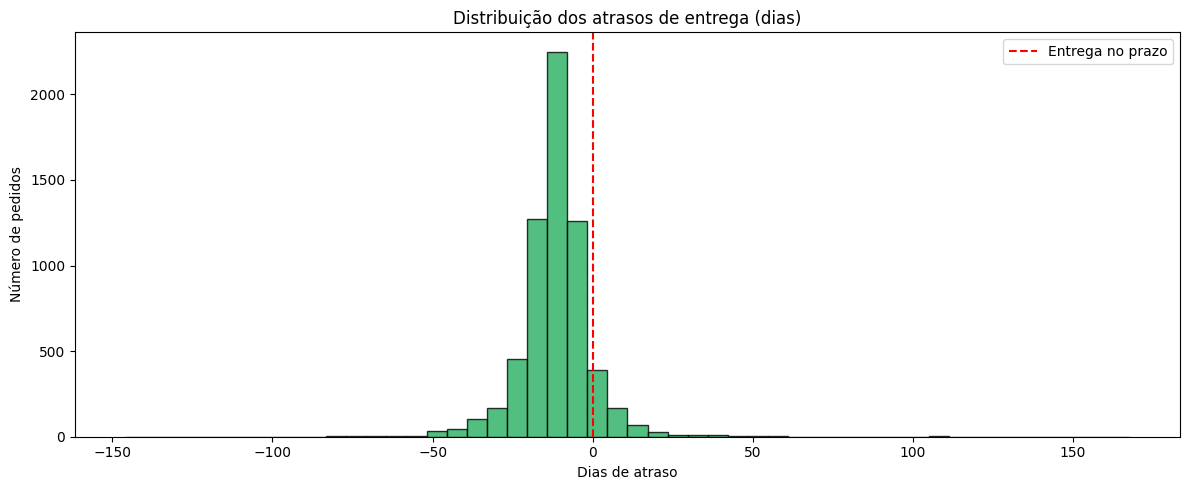

In [32]:
# Visualização avançada de performance e outras métricas logísticas
performance_by_year = performance_by_year.sort_values("order_year")
performance_by_year["order_year"] = performance_by_year["order_year"].astype(int)

x = list(range(len(performance_by_year)))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar([pos - width/2 for pos in x], performance_by_year["avg_processing_days"], width=width, label="Tempo de aprovação (dias)")
plt.bar([pos + width/2 for pos in x], performance_by_year["avg_delivery_delay"], width=width, alpha=0.8, label="Atraso médio de entrega (dias)")
plt.title("Performance logística por ano")
plt.xlabel("Ano")
plt.ylabel("Dias")
plt.xticks(x, performance_by_year["order_year"].astype(str))
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(performance_by_year["order_year"].astype(str), performance_by_year["pct_late_delivery"], color="#d35400")
plt.title("Percentual de entregas atrasadas por ano")
plt.xlabel("Ano")
plt.ylabel("% de entregas atrasadas")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

late_states = (
    state_performance
    .sort_values("pct_late_delivery", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 5))
states = state_top["customer_state"]
plt.bar(states, state_top["total_orders"], color="#2F5597")
plt.title("Top 10 estados por volume de pedidos")
plt.xlabel("Estado")
plt.ylabel("Pedidos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(late_states["customer_state"], late_states["pct_late_delivery"] * 100, color="#c0392b")
plt.title("Top 10 estados com maior taxa de atrasos")
plt.xlabel("Estado")
plt.ylabel("Taxa de atrasos (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
hist_data = orders_log["delivery_delay_days"].dropna()
plt.hist(hist_data, bins=50, color="#27ae60", edgecolor="black", alpha=0.8)
plt.axvline(0, color="red", linestyle="--", label="Entrega no prazo")
plt.title("Distribuição dos atrasos de entrega (dias)")
plt.xlabel("Dias de atraso")
plt.ylabel("Número de pedidos")
plt.legend()
plt.tight_layout()
plt.show()

plt.show()